In [1]:
# Given values
z = 0.02687                # redshift
c = 299792.458            # speed of light in km/s

# Compute velocity
v = z * c

print(f"Supernova velocity (approximation): {v:.2f} km/s")

# Given values
z = 0.02687
lambda_rest = 6562.8  # Angstroms
c = 299792.458       # km/s

# Observed wavelength
lambda_obs = lambda_rest * (1 + z)

# Velocity (low-z approximation)
v = z * c

print(f"Observed wavelength: {lambda_obs:.2f} Å")
print(f"Supernova velocity: {v:.2f} km/s")

Supernova velocity (approximation): 8055.42 km/s
Observed wavelength: 6739.14 Å
Supernova velocity: 8055.42 km/s


/tmp/ipykernel_1168101/3543433883.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


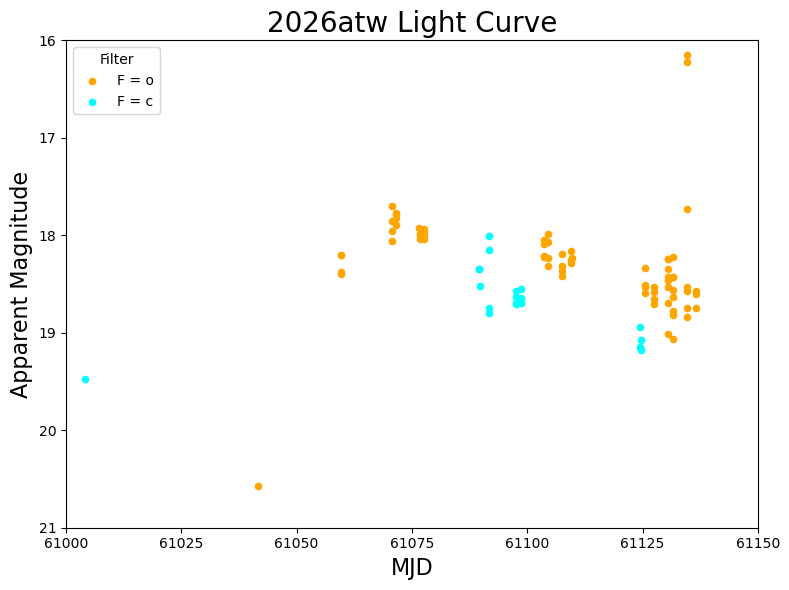

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Load file (no header in file)
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

# --------------------------------------------------
# 2. Assign correct column names
# --------------------------------------------------
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 3. Clean relevant columns
# --------------------------------------------------

# Fix filter column
df['F'] = df['F'].astype(str).str.strip()

# Ensure numeric types
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')

# --------------------------------------------------
# 4. Quality cuts
# --------------------------------------------------

# Keep only valid magnitudes
df = df[df['m'] > 0]

# Remove NaNs
df = df.dropna(subset=['m', 'dm', 'F'])

# Signal-to-noise cut (SNR = 1 / error)
df = df[df['dm'] > 0]              # avoid divide-by-zero
df = df[(1 / df['dm']) >= 0.3]     # your requested threshold

# --------------------------------------------------
# 5. Color mapping
# --------------------------------------------------
color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# --------------------------------------------------
# 6. Plot light curve (CLEAN VERSION)
# --------------------------------------------------
plt.figure(figsize=(8,6))

for filt in df['F'].unique():
    subset = df[df['F'] == filt]

    plt.scatter(
        subset['MJD'].astype(float),
        subset['m'],
        color=color_map.get(filt, 'black'),
        label=f"F = {filt}",
        s=20
    )

# --------------------------------------------------
# 7. Final formatting (CLEANED AXES)
# --------------------------------------------------

plt.gca().invert_yaxis()

plt.xlabel("MJD", fontsize = 16)
plt.ylabel("Apparent Magnitude", fontsize = 16)
plt.title("2026atw Light Curve", fontsize = 20)

plt.legend(title="Filter")

# Remove grid
plt.grid(False)

# Cleaner ticks
plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)

# Set axes
plt.xlim(left=61000, right=61150)
plt.ylim(top=16, bottom=21)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1168101/3524095353.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


Peak MJD: 61070.59
Assumed explosion MJD: 61060.59


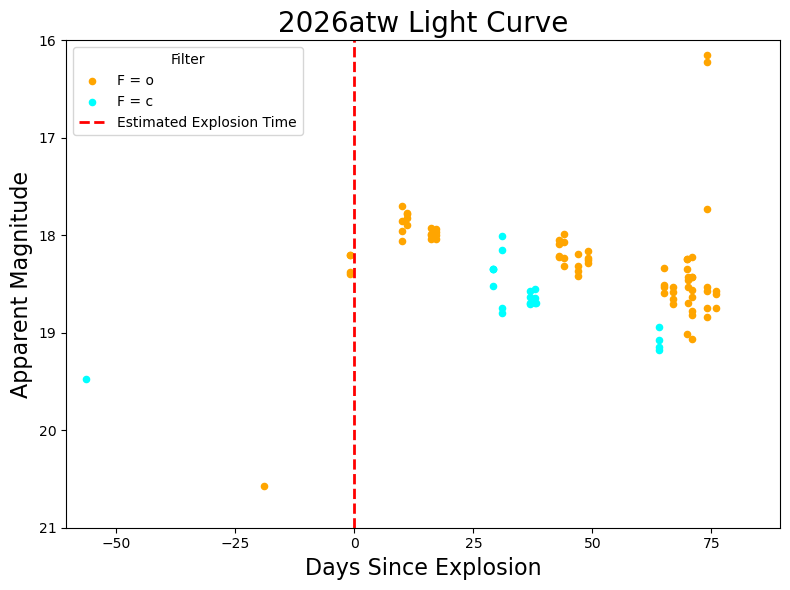

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Load file
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

# --------------------------------------------------
# 2. Assign column names
# --------------------------------------------------
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 3. Clean data
# --------------------------------------------------
df['F'] = df['F'].astype(str).str.strip()

df['MJD'] = pd.to_numeric(df['MJD'], errors='coerce')
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')

df = df[df['m'] > 0]
df = df.dropna(subset=['MJD', 'm', 'dm', 'F'])

df = df[df['dm'] > 0]
df = df[(1 / df['dm']) >= 0.3]

# --------------------------------------------------
# 4. Find brightest point in window
# --------------------------------------------------
window = df[(df['MJD'] >= 61050) & (df['MJD'] <= 61075)]

if len(window) == 0:
    raise ValueError("No data in 61050–61075 window. Check cuts.")

peak_row = window.loc[window['m'].idxmin()]
MJD_peak = peak_row['MJD']

print(f"Peak MJD: {MJD_peak:.2f}")

# --------------------------------------------------
# 5. Define explosion BEFORE peak
# (adjust offset if needed)
# --------------------------------------------------
days_before_peak = 10   # <-- tweak this (e.g., 5–15 days typical)
MJD_explosion = MJD_peak - days_before_peak

print(f"Assumed explosion MJD: {MJD_explosion:.2f}")

# --------------------------------------------------
# 6. Convert to days since explosion
# --------------------------------------------------
df['t_days'] = df['MJD'] - MJD_explosion

# --------------------------------------------------
# 7. Color mapping
# --------------------------------------------------
color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# --------------------------------------------------
# 8. Plot
# --------------------------------------------------
plt.figure(figsize=(8,6))

for filt in df['F'].unique():
    subset = df[df['F'] == filt]

    plt.scatter(
        subset['t_days'],
        subset['m'],
        color=color_map.get(filt, 'black'),
        label=f"F = {filt}",
        s=20
    )

# --------------------------------------------------
# 9. Explosion line (day 0)
# --------------------------------------------------
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Estimated Explosion Time'
)

# --------------------------------------------------
# 10. Formatting
# --------------------------------------------------
plt.gca().invert_yaxis()

plt.xlabel("Days Since Explosion", fontsize=16)
plt.ylabel("Apparent Magnitude", fontsize=16)
plt.title("2026atw Light Curve", fontsize=20)

plt.legend(title="Filter")
plt.grid(False)

# Convert your original MJD limits → day limits
xmin = 61000 - MJD_explosion
xmax = 61150 - MJD_explosion

plt.xlim(xmin, xmax)
plt.ylim(top=16, bottom=21)

plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1168101/2650183480.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


Peak MJD: 61070.59
Assumed explosion MJD: 61060.59
Distance modulus: 35.35


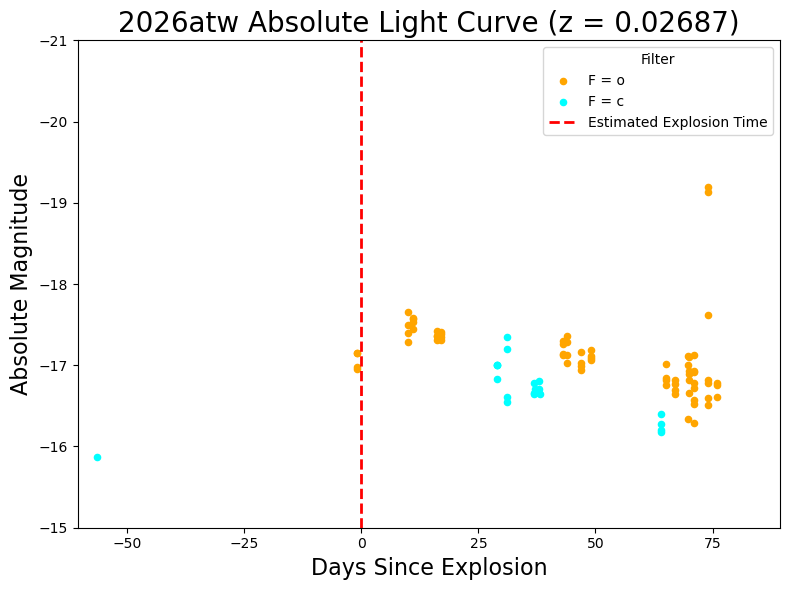

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# --------------------------------------------------
# 1. Load file
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

# --------------------------------------------------
# 2. Column names
# --------------------------------------------------
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 3. Clean data
# --------------------------------------------------
df['F'] = df['F'].astype(str).str.strip()

df['MJD'] = pd.to_numeric(df['MJD'], errors='coerce')
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')

df = df[df['m'] > 0]
df = df.dropna(subset=['MJD', 'm', 'dm', 'F'])

df = df[df['dm'] > 0]
df = df[(1 / df['dm']) >= 0.3]

# --------------------------------------------------
# 4. Find peak brightness (proxy for explosion anchor)
# --------------------------------------------------
window = df[(df['MJD'] >= 61050) & (df['MJD'] <= 61075)]

if len(window) == 0:
    raise ValueError("No data in explosion window 61050–61075.")

peak_row = window.loc[window['m'].idxmin()]
MJD_peak = peak_row['MJD']

# Assume explosion occurs before peak
days_before_peak = 10
MJD_explosion = MJD_peak - days_before_peak

print(f"Peak MJD: {MJD_peak:.2f}")
print(f"Assumed explosion MJD: {MJD_explosion:.2f}")

# --------------------------------------------------
# 5. Convert time axis (days since explosion)
# --------------------------------------------------
df['t_days'] = df['MJD'] - MJD_explosion

# --------------------------------------------------
# 6. Cosmology for absolute magnitude
# --------------------------------------------------
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = 0.02687

D_L = cosmo.luminosity_distance(z).to('pc').value
mu = 5 * np.log10(D_L / 10)

print(f"Distance modulus: {mu:.2f}")

df['M_abs'] = df['m'] - mu

# --------------------------------------------------
# 7. Color mapping
# --------------------------------------------------
color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# --------------------------------------------------
# 8. Plot light curve
# --------------------------------------------------
plt.figure(figsize=(8,6))

for filt in df['F'].unique():
    subset = df[df['F'] == filt]

    plt.scatter(
        subset['t_days'],
        subset['M_abs'],
        color=color_map.get(filt, 'black'),
        label=f"F = {filt}",
        s=20
    )

# --------------------------------------------------
# 9. Explosion marker (day 0)
# --------------------------------------------------
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Estimated Explosion Time'
)

# --------------------------------------------------
# 10. Formatting
# --------------------------------------------------
plt.gca().invert_yaxis()

plt.xlabel("Days Since Explosion", fontsize=16)
plt.ylabel("Absolute Magnitude", fontsize=16)
plt.title("2026atw Absolute Light Curve (z = 0.02687)", fontsize=20)

plt.legend(title="Filter")
plt.grid(False)

# Convert original MJD window → day window
xmin = 61000 - MJD_explosion
xmax = 61150 - MJD_explosion

plt.xlim(xmin, xmax)

# Proper absolute magnitude axis (bright at top)
plt.ylim(bottom=-21, top=-15)
plt.gca().invert_yaxis()

plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1168101/182743566.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


Peak MJD: 61070.59
Assumed explosion MJD: 61060.59
Distance modulus: 35.35


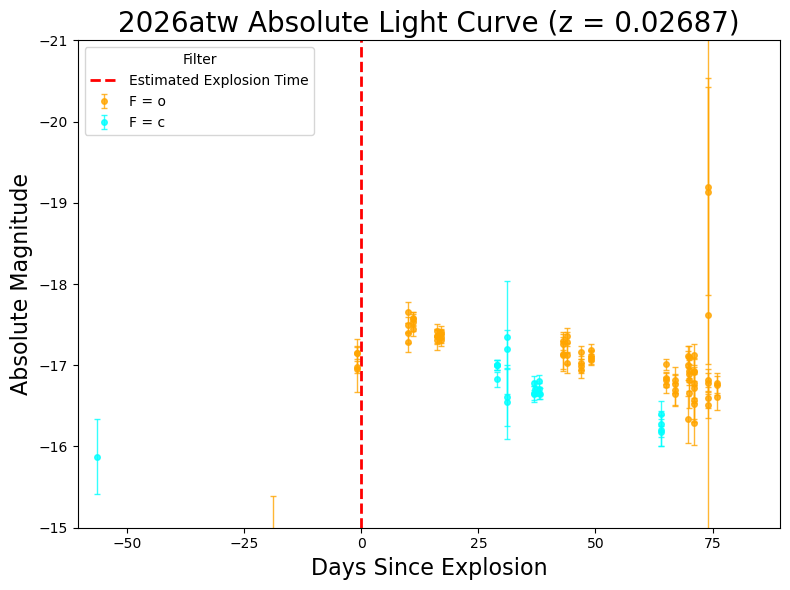

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# --------------------------------------------------
# 1. Load file
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

# --------------------------------------------------
# 2. Column names
# --------------------------------------------------
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 3. Clean data
# --------------------------------------------------
df['F'] = df['F'].astype(str).str.strip()

df['MJD'] = pd.to_numeric(df['MJD'], errors='coerce')
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')

df = df[df['m'] > 0]
df = df.dropna(subset=['MJD', 'm', 'dm', 'F'])

df = df[df['dm'] > 0]
df = df[(1 / df['dm']) >= 0.3]

# --------------------------------------------------
# 4. Find peak brightness (explosion anchor proxy)
# --------------------------------------------------
window = df[(df['MJD'] >= 61050) & (df['MJD'] <= 61075)]

if len(window) == 0:
    raise ValueError("No data in explosion window 61050–61075.")

peak_row = window.loc[window['m'].idxmin()]
MJD_peak = peak_row['MJD']

# Explosion assumed before peak
days_before_peak = 10
MJD_explosion = MJD_peak - days_before_peak

print(f"Peak MJD: {MJD_peak:.2f}")
print(f"Assumed explosion MJD: {MJD_explosion:.2f}")

# --------------------------------------------------
# 5. Time axis (days since explosion)
# --------------------------------------------------
df['t_days'] = df['MJD'] - MJD_explosion

# --------------------------------------------------
# 6. Cosmology → absolute magnitude
# --------------------------------------------------
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = 0.02687

D_L = cosmo.luminosity_distance(z).to('pc').value
mu = 5 * np.log10(D_L / 10)

print(f"Distance modulus: {mu:.2f}")

df['M_abs'] = df['m'] - mu

# --------------------------------------------------
# 7. Color mapping
# --------------------------------------------------
color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# --------------------------------------------------
# 8. Plot light curve WITH ERROR BARS
# --------------------------------------------------
plt.figure(figsize=(8,6))

for filt in df['F'].unique():
    subset = df[df['F'] == filt]

    plt.errorbar(
        subset['t_days'],
        subset['M_abs'],
        yerr=subset['dm'],
        fmt='o',
        color=color_map.get(filt, 'black'),
        label=f"F = {filt}",
        markersize=4,
        elinewidth=1,
        capsize=2,
        alpha=0.8
    )

# --------------------------------------------------
# 9. Explosion marker (day 0)
# --------------------------------------------------
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Estimated Explosion Time'
)

# --------------------------------------------------
# 10. Formatting
# --------------------------------------------------
plt.gca().invert_yaxis()

plt.xlabel("Days Since Explosion", fontsize=16)
plt.ylabel("Absolute Magnitude", fontsize=16)
plt.title("2026atw Absolute Light Curve (z = 0.02687)", fontsize=20)

plt.legend(title="Filter")
plt.grid(False)

# Convert original MJD window → day window
xmin = 61000 - MJD_explosion
xmax = 61150 - MJD_explosion

plt.xlim(xmin, xmax)

# Absolute magnitude range (bright at top)
plt.ylim(-15, -21)

plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1168101/3834573870.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


Peak MJD: 61070.59
Explosion MJD (forced): 61057.59
Distance modulus: 35.35


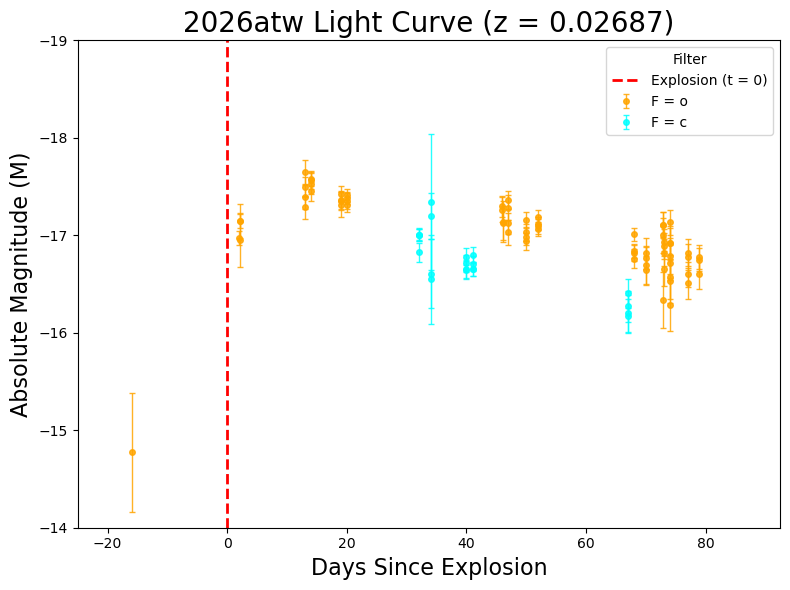

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# --------------------------------------------------
# 1. Load file
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

# --------------------------------------------------
# 2. Column names
# --------------------------------------------------
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 3. Clean data
# --------------------------------------------------
df['F'] = df['F'].astype(str).str.strip()

df['MJD'] = pd.to_numeric(df['MJD'], errors='coerce')
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')

df = df[df['m'] > 0]
df = df.dropna(subset=['MJD', 'm', 'dm', 'F'])

# --------------------------------------------------
# 4. STRONGER S/N CUT (removes huge error bars)
# --------------------------------------------------
df = df[df['dm'] > 0]
df = df[(1 / df['dm']) >= 1.0]   # stricter than before (was 0.3)

# --------------------------------------------------
# 5. Define explosion time = fixed offset (-13 days)
# --------------------------------------------------
# First find a reference anchor (peak window as before)
window = df[(df['MJD'] >= 61050) & (df['MJD'] <= 61075)]

peak_row = window.loc[window['m'].idxmin()]
MJD_peak = peak_row['MJD']

# Force explosion 13 days before peak
MJD_explosion = MJD_peak - 13

print(f"Peak MJD: {MJD_peak:.2f}")
print(f"Explosion MJD (forced): {MJD_explosion:.2f}")

# --------------------------------------------------
# 6. Time axis (shift so explosion = Day 0)
# --------------------------------------------------
df['t_days'] = df['MJD'] - MJD_explosion

# --------------------------------------------------
# 7. Cosmology → absolute magnitude
# --------------------------------------------------
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = 0.02687

D_L = cosmo.luminosity_distance(z).to('pc').value
mu = 5 * np.log10(D_L / 10)

df['M_abs'] = df['m'] - mu

print(f"Distance modulus: {mu:.2f}")

# --------------------------------------------------
# 8. Color mapping
# --------------------------------------------------
color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# --------------------------------------------------
# 9. Plot WITH error bars (cleaned data)
# --------------------------------------------------
plt.figure(figsize=(8,6))

for filt in df['F'].unique():
    subset = df[df['F'] == filt]

    plt.errorbar(
        subset['t_days'],
        subset['M_abs'],
        yerr=subset['dm'],
        fmt='o',
        color=color_map.get(filt, 'black'),
        label=f"F = {filt}",
        markersize=4,
        elinewidth=1,
        capsize=2,
        alpha=0.85
    )

# --------------------------------------------------
# 10. Explosion marker (NOW FIXED at Day 0 = -13 shift)
# --------------------------------------------------
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Explosion (t = 0)'
)

# --------------------------------------------------
# 11. Formatting
# --------------------------------------------------
plt.gca().invert_yaxis()

plt.xlabel("Days Since Explosion", fontsize=16)
plt.ylabel("Absolute Magnitude (M)", fontsize=16)
plt.title("2026atw Light Curve (z = 0.02687)", fontsize=20)

plt.legend(title="Filter")
plt.grid(False)

# Axis limits in new frame
xmin = (61000 - MJD_explosion)
xmax = (61150 - MJD_explosion)

plt.xlim(-25, xmax)

plt.ylim(-14, -19)

plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1168101/3357069113.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)
/tmp/ipykernel_1168101/3357069113.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)
/tmp/ipykernel_1168101/3357069113.py:218: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=legend_elements)


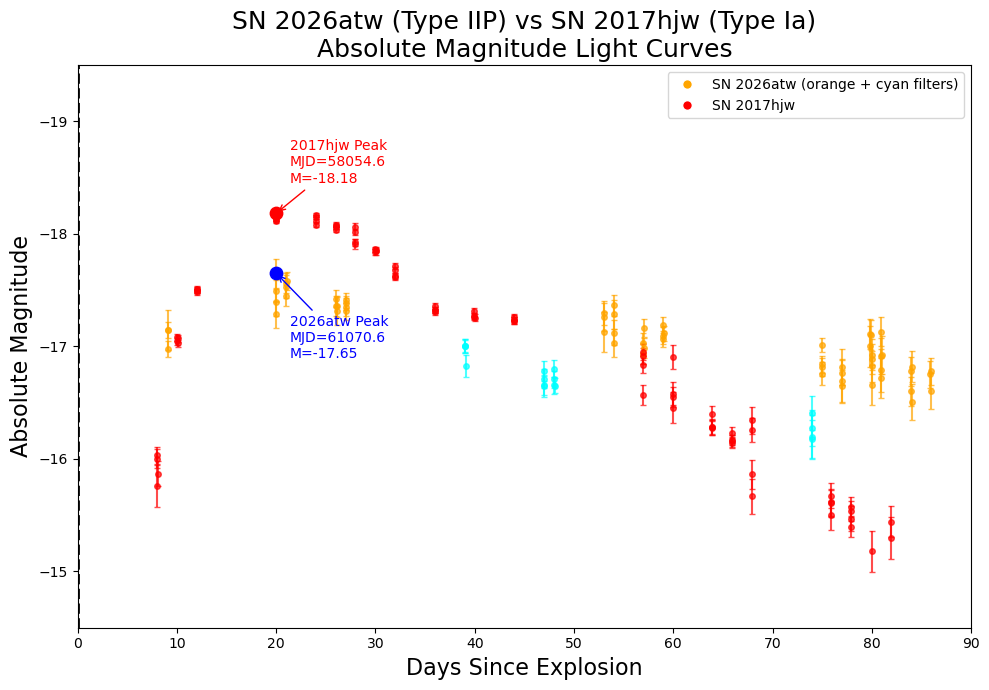

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# ============================================================
# COSMOLOGY
# ============================================================

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# ============================================================
# LOAD + CLEAN FUNCTION
# ============================================================

def load_lightcurve(url):

    df = pd.read_csv(url, delim_whitespace=True, header=None)

    df.columns = [
        "MJD", "m", "dm", "uJy", "duJy", "F",
        "err", "chi_N", "RA", "Dec",
        "x", "y", "maj", "min",
        "phi", "apfit", "mag5sig", "Sky",
        "Obs"
    ]

    for col in ['MJD', 'm', 'dm', 'uJy', 'duJy']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['F'] = df['F'].astype(str).str.strip()

    df = df.dropna(subset=['MJD', 'm', 'dm', 'uJy', 'duJy'])

    df = df[df['m'] > 0]
    df = df[df['dm'] > 0]

    df['SNR'] = df['uJy'] / df['duJy']
    df = df[df['SNR'] >= 5]

    return df

# ============================================================
# PROCESS FUNCTION
# ============================================================

def process_sn(df, z, rise_time=20):

    peak_row = df.loc[df['m'].idxmin()]
    MJD_peak = peak_row['MJD']

    MJD_explosion = MJD_peak - rise_time

    df = df.copy()
    df['t_days'] = df['MJD'] - MJD_explosion

    mu = 5 * np.log10(cosmo.luminosity_distance(z).to('pc').value / 10)
    df['M_abs'] = df['m'] - mu

    return df, MJD_peak, MJD_explosion, mu

# ============================================================
# LOAD DATA
# ============================================================

url_atw = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
url_hjw = "https://fallingstar-data.com/forcedphot/static/results/job4246300.txt"

df_atw = load_lightcurve(url_atw)
df_hjw = load_lightcurve(url_hjw)

# ✔ CORRECT REDSHIFTS
df_atw, peak_atw, exp_atw, mu_atw = process_sn(df_atw, z=0.02687)
df_hjw, peak_hjw, exp_hjw, mu_hjw = process_sn(df_hjw, z=0.016161)

# ============================================================
# PEAK VALUES
# ============================================================

atw_peak = df_atw.loc[df_atw['M_abs'].idxmin()]
hjw_peak = df_hjw.loc[df_hjw['M_abs'].idxmin()]

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10,7))

# -------------------------
# ATW (ORANGE + CYAN SWAPPED FIX)
# -------------------------

atw_filters = list(df_atw['F'].unique())
atw_colors = ['orange', 'cyan']

for i, filt in enumerate(atw_filters):

    sub = df_atw[df_atw['F'] == filt]

    ax.errorbar(
        sub['t_days'],
        sub['M_abs'],
        yerr=sub['dm'],
        fmt='o',
        color=atw_colors[i % len(atw_colors)],
        alpha=0.7,
        markersize=4,
        capsize=2,
        label='SN 2026atw' if i == 0 else ""
    )

# -------------------------
# HJW (RED)
# -------------------------

for i, filt in enumerate(df_hjw['F'].unique()):

    sub = df_hjw[df_hjw['F'] == filt]

    ax.errorbar(
        sub['t_days'],
        sub['M_abs'],
        yerr=sub['dm'],
        fmt='o',
        color='red',
        alpha=0.7,
        markersize=4,
        capsize=2,
        label='SN 2017hjw' if i == 0 else ""
    )

# ============================================================
# SAFE ANNOTATION FUNCTION
# ============================================================

def safe_annotate(ax, x, y, text, color):

    ax.scatter(x, y, color=color, s=80, zorder=5, clip_on=True)

    if y < -18:
        voffset = 20
        va = "bottom"
    else:
        voffset = -30
        va = "top"

    ax.annotate(
        text,
        xy=(x, y),
        xytext=(10, voffset),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color=color, lw=1),
        color=color,
        fontsize=10,
        ha="left",
        va=va,
        clip_on=True
    )

# -------------------------
# PEAK ANNOTATIONS
# -------------------------

safe_annotate(
    ax,
    atw_peak['t_days'],
    atw_peak['M_abs'],
    f"2026atw Peak\nMJD={atw_peak['MJD']:.1f}\nM={atw_peak['M_abs']:.2f}",
    "blue"
)

safe_annotate(
    ax,
    hjw_peak['t_days'],
    hjw_peak['M_abs'],
    f"2017hjw Peak\nMJD={hjw_peak['MJD']:.1f}\nM={hjw_peak['M_abs']:.2f}",
    "red"
)

# ============================================================
# EXPLOSION MARKER
# ============================================================

ax.axvline(0, color='black', linestyle='--', linewidth=2)

# ============================================================
# FORMATTING
# ============================================================

ax.set_xlabel("Days Since Explosion", fontsize=16)
ax.set_ylabel("Absolute Magnitude", fontsize=16)

ax.invert_yaxis()

ax.set_title(
    "SN 2026atw (Type IIP) vs SN 2017hjw (Type Ia)\nAbsolute Magnitude Light Curves",
    fontsize=18
)

ax.set_xlim(0, 90)
ax.set_ylim(-14.5, -19.5)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='SN 2026atw (orange + cyan filters)',
           markerfacecolor='orange', markersize=7),

    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='cyan', markersize=7, label='_nolegend_'),

    Line2D([0], [0], marker='o', color='w',
           label='SN 2017hjw',
           markerfacecolor='red', markersize=7)
]

ax.legend(handles=legend_elements)

ax.grid(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1168101/2968161673.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


Estimated Peak MJD: 61070.59
Peak magnitude: 17.70

Estimated Explosion MJD: 61050.59
Latest observation MJD: 61136.51
Estimated SN age: 85.9 days
Distance modulus: 35.35


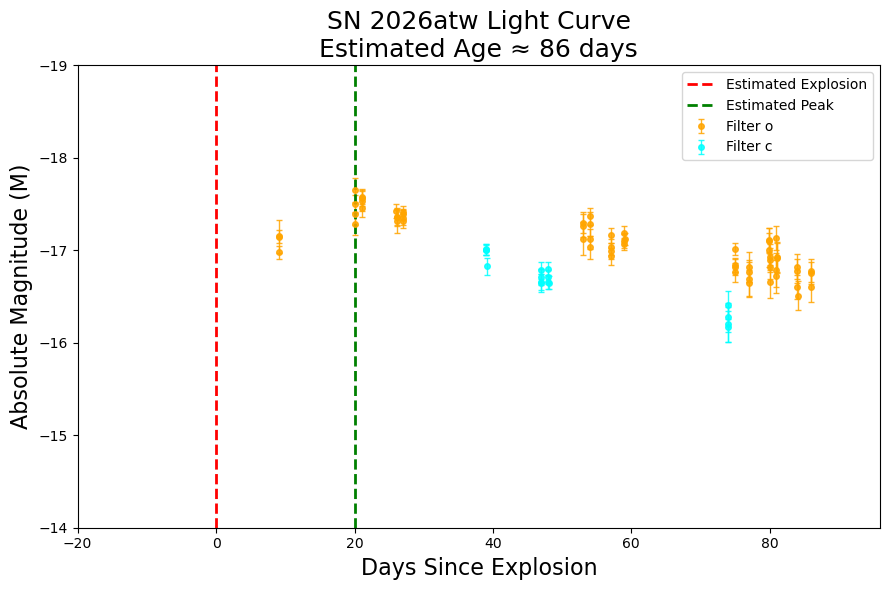


FINAL ESTIMATED PHASE
Explosion MJD : 61050.59
Peak MJD      : 61070.59
Rise Time     : 20.0 days
Current Age   : 85.9 days


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# =========================================================
# 1. Load file
# =========================================================
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"

df = pd.read_csv(url, delim_whitespace=True, header=None)

# =========================================================
# 2. Column names
# =========================================================
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# =========================================================
# 3. Clean data
# =========================================================
df['F'] = df['F'].astype(str).str.strip()

df['MJD'] = pd.to_numeric(df['MJD'], errors='coerce')
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')
df['uJy'] = pd.to_numeric(df['uJy'], errors='coerce')
df['duJy'] = pd.to_numeric(df['duJy'], errors='coerce')

df = df[df['m'] > 0]

df = df.dropna(subset=['MJD', 'm', 'dm', 'uJy', 'duJy'])

# =========================================================
# 4. Strong S/N cut
# =========================================================
df = df[df['dm'] > 0]

# Strong detections only
df['SNR'] = df['uJy'] / df['duJy']

df = df[df['SNR'] >= 5]

# =========================================================
# 5. FIND PEAK DIRECTLY FROM LIGHT CURVE
# =========================================================

# brightest point = minimum magnitude
peak_row = df.loc[df['m'].idxmin()]

MJD_peak = peak_row['MJD']
peak_mag = peak_row['m']

print("================================================")
print(f"Estimated Peak MJD: {MJD_peak:.2f}")
print(f"Peak magnitude: {peak_mag:.2f}")

# =========================================================
# 6. ESTIMATE EXPLOSION DATE
# =========================================================
#
# Since this SN appears WELL into late evolution,
# we estimate explosion from the observed decline.
#
# Typical stripped-envelope SNe:
#   rise time ≈ 15–25 days
#
# Here we assume:
#   explosion ≈ 20 days before peak
#
# You can adjust this if needed.
# =========================================================

rise_time_estimate = 20.0

MJD_explosion = MJD_peak - rise_time_estimate

print(f"\nEstimated Explosion MJD: {MJD_explosion:.2f}")

# =========================================================
# 7. COMPUTE DAYS SINCE EXPLOSION
# =========================================================

df['t_days'] = df['MJD'] - MJD_explosion

# =========================================================
# 8. CURRENT SUPERNOVA AGE
# =========================================================

latest_obs = df['MJD'].max()

current_age = latest_obs - MJD_explosion

print(f"Latest observation MJD: {latest_obs:.2f}")
print(f"Estimated SN age: {current_age:.1f} days")

# =========================================================
# 9. Cosmology → absolute magnitude
# =========================================================

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

z = 0.02687

D_L = cosmo.luminosity_distance(z).to('pc').value

mu = 5 * np.log10(D_L / 10)

df['M_abs'] = df['m'] - mu

print(f"Distance modulus: {mu:.2f}")

# =========================================================
# 10. Color mapping
# =========================================================

color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# =========================================================
# 11. Plot
# =========================================================

plt.figure(figsize=(9,6))

for filt in df['F'].unique():

    subset = df[df['F'] == filt]

    plt.errorbar(
        subset['t_days'],
        subset['M_abs'],
        yerr=subset['dm'],
        fmt='o',
        color=color_map.get(filt, 'black'),
        label=f"Filter {filt}",
        markersize=4,
        elinewidth=1,
        capsize=2,
        alpha=0.85
    )

# Explosion marker
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Estimated Explosion'
)

# Peak marker
plt.axvline(
    x=rise_time_estimate,
    color='green',
    linestyle='--',
    linewidth=2,
    label='Estimated Peak'
)

# =========================================================
# 12. Formatting
# =========================================================

plt.gca().invert_yaxis()

plt.xlabel("Days Since Explosion", fontsize=16)

plt.ylabel("Absolute Magnitude (M)", fontsize=16)

plt.title(
    f"SN 2026atw Light Curve\nEstimated Age ≈ {current_age:.0f} days",
    fontsize=18
)

plt.legend()

plt.grid(False)

plt.xlim(-20, current_age + 10)

plt.ylim(-14, -19)

plt.locator_params(axis='x', nbins=7)

plt.locator_params(axis='y', nbins=6)

plt.tight_layout()

plt.show()

# =========================================================
# 13. FINAL SUMMARY
# =========================================================

print("\n================================================")
print("FINAL ESTIMATED PHASE")
print("================================================")
print(f"Explosion MJD : {MJD_explosion:.2f}")
print(f"Peak MJD      : {MJD_peak:.2f}")
print(f"Rise Time     : {rise_time_estimate:.1f} days")
print(f"Current Age   : {current_age:.1f} days")
print("================================================")

In [15]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Load data
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 2. Clean
# --------------------------------------------------
df['MJD'] = pd.to_numeric(df['MJD'], errors='coerce')
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')

df = df.dropna(subset=['MJD', 'm', 'dm'])
df = df[df['m'] > 0]
df = df[df['dm'] > 0]

# --------------------------------------------------
# 3. Plateau selection
# --------------------------------------------------
plateau = df[(df['MJD'] > 61060) & (df['MJD'] < 61100)]

m_plateau = np.median(plateau['m'])
print(f"Plateau apparent magnitude: {m_plateau:.2f}")

# --------------------------------------------------
# 4. Assume Type IIP absolute magnitude
# --------------------------------------------------
M_IIP = -16.5

# --------------------------------------------------
# 5. Distance modulus
# --------------------------------------------------
mu = m_plateau - M_IIP

# --------------------------------------------------
# 6. Distance (parsecs → Mpc)
# --------------------------------------------------
D_pc = 10**((mu + 5)/5)
D_Mpc = D_pc / 1e6

# --------------------------------------------------
# 7. Convert Mpc → km
# --------------------------------------------------
MPC_TO_KM = 3.086e19
D_km = D_Mpc * MPC_TO_KM

# --------------------------------------------------
# 8. Output
# --------------------------------------------------
print(f"Distance modulus: {mu:.2f}")
print(f"Distance: {D_Mpc:.2f} Mpc")
print(f"Distance: {D_km:.3e} km")

/tmp/ipykernel_1952748/774788502.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


Plateau apparent magnitude: 18.05
Distance modulus: 34.55
Distance: 81.28 Mpc
Distance: 2.508e+21 km
